# Comprehensive Statistics and Probability Course
## Complete Guide with Examples, Datasets, and Exercises

This notebook covers all fundamental and advanced concepts in statistics and probability with practical examples and hands-on exercises.

In [10]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm, binom, poisson, chi2, t
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

---
# Module 8: Foundations of Statistics and Probability

## Topic 1: Introduction to Statistics

### Concepts Covered:
- **Basic Statistics Terms**: Population vs Sample, Parameters vs Statistics
- **Types of Statistics**: Descriptive vs Inferential Statistics
- **Types of Data**: Qualitative (Categorical) vs Quantitative (Numerical)
- **Levels of Measurement**: Nominal, Ordinal, Interval, Ratio
- **Measures of Central Tendency**: Mean, Median, Mode
- **Measures of Dispersion**: Range, Variance, Standard Deviation, IQR

### Detailed Explanations:

#### 1. Basic Statistics Terms
- **Population**: Entire collection of all possible observations
- **Sample**: A subset of the population used for analysis
- **Parameter**: A numerical description of a population characteristic
- **Statistic**: A numerical description of a sample characteristic

#### 2. Types of Data
- **Qualitative Data**: Non-numerical data describing qualities (e.g., color, gender)
- **Quantitative Data**: Numerical data (e.g., height, weight, age)
  - Discrete: Countable values (e.g., number of students)
  - Continuous: Any value in a range (e.g., height)

#### 3. Measures of Central Tendency
- **Mean**: Average of all values, sensitive to outliers
- **Median**: Middle value, robust to outliers
- **Mode**: Most frequent value, good for categorical data

## Example Dataset: Student Performance Data

In [11]:
# Create sample dataset - Student performance
np.random.seed(42)
student_data = {
    'Student_ID': range(1, 101),
    'Age': np.random.normal(20, 2, 100).astype(int),
    'Math_Score': np.random.normal(75, 15, 100),
    'Science_Score': np.random.normal(72, 14, 100),
    'English_Score': np.random.normal(70, 16, 100),
    'Gender': np.random.choice(['Male', 'Female'], 100),
    'Study_Hours': np.random.uniform(2, 8, 100)
}

df_students = pd.DataFrame(student_data)
print("Dataset Shape:", df_students.shape)
print("\nFirst few rows:")
print(df_students.head(10))
print("\nData Info:")
print(df_students.info())

Dataset Shape: (100, 7)

First few rows:
   Student_ID  Age  Math_Score  Science_Score  English_Score  Gender  \
0           1   20   53.769439      77.009023      56.736080    Male   
1           2   19   68.690320      79.850983      61.037103    Male   
2           3   21   69.859282      87.162717      81.956698    Male   
3           4   23   62.965841      86.753229      79.765924    Male   
4           5   19   72.580714      52.712629      69.665574  Female   
5           6   19   81.060763      58.870449      71.877238    Male   
6           7   23  103.292789      79.210494      90.442638  Female   
7           8   21   77.618667      79.193003      60.534858  Female   
8           9   19   78.863256      79.210668      78.753558    Male   
9          10   21   73.883311     125.938241      66.764918    Male   

   Study_Hours  
0     2.882441  
1     7.559526  
2     4.952698  
3     3.549466  
4     4.754815  
5     7.880195  
6     4.955709  
7     3.972510  
8     5.80040

### Exercise 1.1: Calculate Measures of Central Tendency

In [12]:
# Exercise 1.1: Central Tendency
print("="*60)
print("MEASURES OF CENTRAL TENDENCY - Math Scores")
print("="*60)

math_scores = df_students['Math_Score']

mean_score = math_scores.mean()
median_score = math_scores.median()
mode_score = math_scores.mode()[0]

print(f"Mean:   {mean_score:.2f}")
print(f"Median: {median_score:.2f}")
print(f"Mode:   {mode_score:.2f}")
print(f"\nInterpretation: The average math score is {mean_score:.2f} points")
print(f"Half of students scored below {median_score:.2f} points")

MEASURES OF CENTRAL TENDENCY - Math Scores
Mean:   75.33
Median: 76.26
Mode:   46.22

Interpretation: The average math score is 75.33 points
Half of students scored below 76.26 points


### Exercise 1.2: Calculate Measures of Dispersion

In [13]:
# Exercise 1.2: Measures of Dispersion
print("\n" + "="*60)
print("MEASURES OF DISPERSION - Math Scores")
print("="*60)

range_score = math_scores.max() - math_scores.min()
variance = math_scores.var()
std_dev = math_scores.std()
iqr = math_scores.quantile(0.75) - math_scores.quantile(0.25)

print(f"Range:              {range_score:.2f}")
print(f"Variance:           {variance:.2f}")
print(f"Standard Deviation: {std_dev:.2f}")
print(f"IQR (Q3-Q1):        {iqr:.2f}")

print(f"\nInterpretation:")
print(f"- Scores vary by {range_score:.2f} points between highest and lowest")
print(f"- On average, scores deviate {std_dev:.2f} points from the mean")
print(f"- Middle 50% of scores span {iqr:.2f} points")


MEASURES OF DISPERSION - Math Scores
Range:              69.58
Variance:           204.63
Standard Deviation: 14.31
IQR (Q3-Q1):        20.16

Interpretation:
- Scores vary by 69.58 points between highest and lowest
- On average, scores deviate 14.31 points from the mean
- Middle 50% of scores span 20.16 points


### Exercise 1.3: Visualize Descriptive Statistics

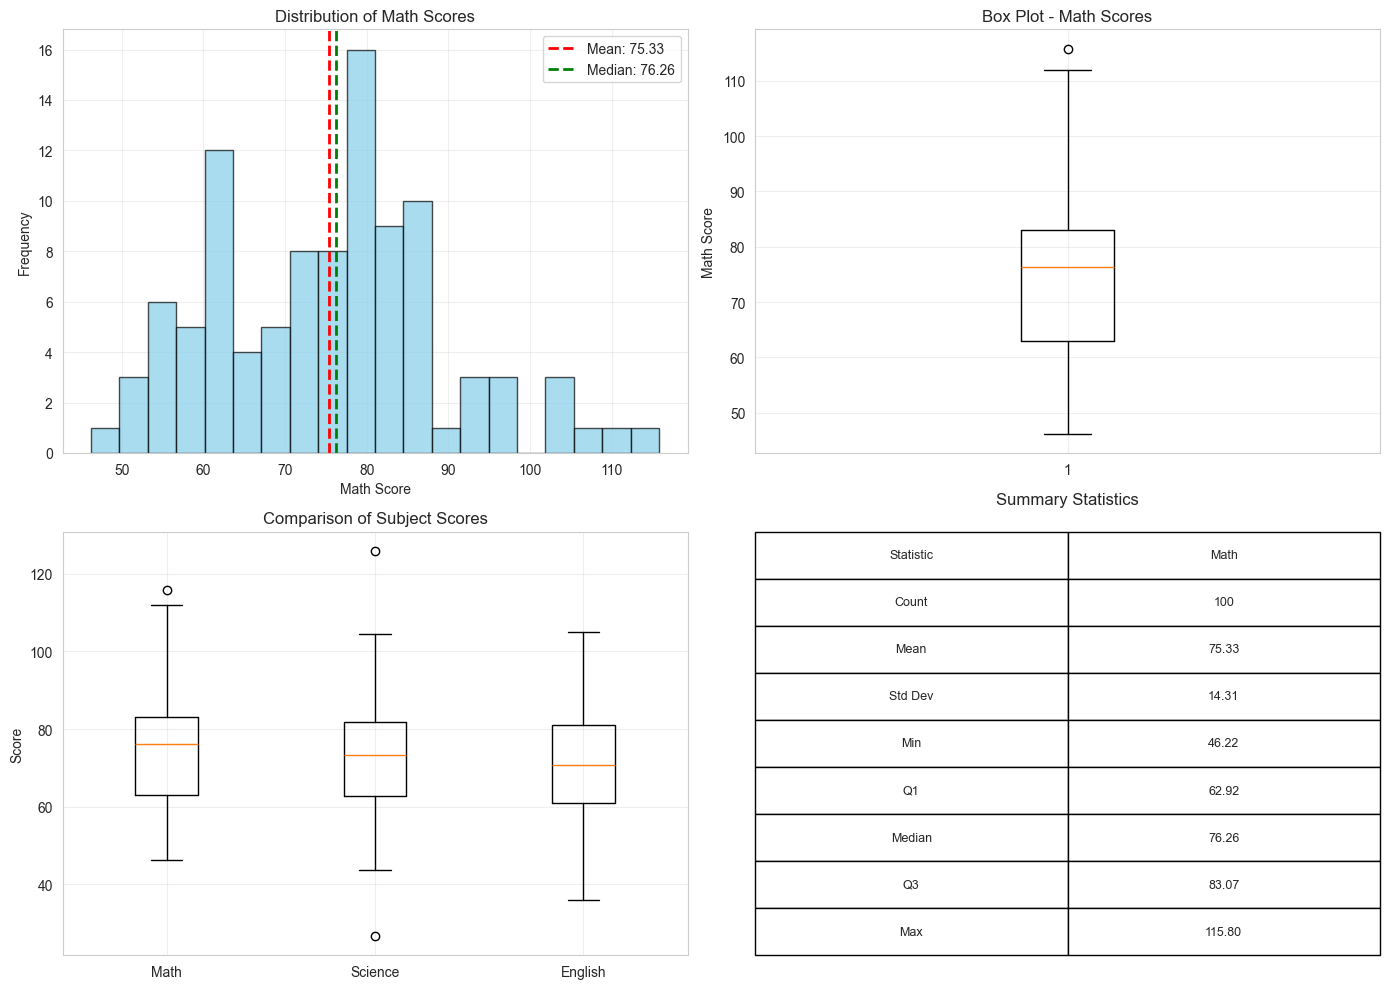

Visualization complete!


In [14]:
# Exercise 1.3: Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram with mean, median lines
ax1 = axes[0, 0]
ax1.hist(math_scores, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
ax1.axvline(mean_score, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_score:.2f}')
ax1.axvline(median_score, color='green', linestyle='--', linewidth=2, label=f'Median: {median_score:.2f}')
ax1.set_xlabel('Math Score')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Math Scores')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Box plot
ax2 = axes[0, 1]
box_plot = ax2.boxplot(math_scores, vert=True)
ax2.set_ylabel('Math Score')
ax2.set_title('Box Plot - Math Scores')
ax2.grid(True, alpha=0.3)

# Compare all three subjects
ax3 = axes[1, 0]
scores_data = [df_students['Math_Score'], df_students['Science_Score'], df_students['English_Score']]
ax3.boxplot(scores_data, labels=['Math', 'Science', 'English'])
ax3.set_ylabel('Score')
ax3.set_title('Comparison of Subject Scores')
ax3.grid(True, alpha=0.3)

# Summary statistics table
ax4 = axes[1, 1]
ax4.axis('tight')
ax4.axis('off')

summary_stats = pd.DataFrame({
    'Statistic': ['Count', 'Mean', 'Std Dev', 'Min', 'Q1', 'Median', 'Q3', 'Max'],
    'Math': [
        len(df_students['Math_Score']),
        f"{df_students['Math_Score'].mean():.2f}",
        f"{df_students['Math_Score'].std():.2f}",
        f"{df_students['Math_Score'].min():.2f}",
        f"{df_students['Math_Score'].quantile(0.25):.2f}",
        f"{df_students['Math_Score'].median():.2f}",
        f"{df_students['Math_Score'].quantile(0.75):.2f}",
        f"{df_students['Math_Score'].max():.2f}"
    ]
})

table = ax4.table(cellText=summary_stats.values, colLabels=summary_stats.columns,
                  cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(9)
ax4.set_title('Summary Statistics', pad=20)

plt.tight_layout()
plt.show()

print("Visualization complete!")

---
## Topic 2: Exploring Random Variables and Probability

### Concepts Covered:
- **Random Variables**: Discrete and Continuous
- **Set Theory**: Union, Intersection, Complement
- **Probability**: Basic rules, Conditional probability, Independence
- **Skewness**: Measure of asymmetry in distribution
- **Covariance & Correlation**: Relationship between variables
- **Probability Density/Distribution Function**

### Detailed Explanations:

#### Random Variables
A random variable is a function that assigns numerical values to outcomes of a random experiment.
- **Discrete**: Takes specific values (0, 1, 2, ...)
- **Continuous**: Takes any value in an interval

#### Probability Rules
- **P(A) = favorable outcomes / total outcomes**
- **P(A ∪ B) = P(A) + P(B) - P(A ∩ B)** (Addition Rule)
- **P(A|B) = P(A ∩ B) / P(B)** (Conditional Probability)
- **P(A|B) = P(A)** if A and B are independent

#### Covariance & Correlation
- **Covariance**: Measures direction of relationship (can be any value)
- **Correlation**: Standardized covariance, ranges from -1 to 1

### Exercise 2.1: Random Variables and Probability

In [15]:
print("\n" + "="*60)
print("RANDOM VARIABLES & PROBABILITY")
print("="*60)

# Example: Rolling a die
print("\n1. DISCRETE RANDOM VARIABLE - Rolling a Fair Die")
print("-" * 50)

# Probability distribution for a fair die
outcomes = np.array([1, 2, 3, 4, 5, 6])
probabilities = np.array([1/6] * 6)

print("Outcome:      ", outcomes)
print("Probability:  ", np.round(probabilities, 4))
print(f"\nP(X = 3) = {probabilities[2]:.4f}")
print(f"P(X > 3) = P(X=4) + P(X=5) + P(X=6) = {sum(probabilities[3:]):.4f}")
print(f"P(X ≤ 2) = {sum(probabilities[:2]):.4f}")

# Expected value (mean)
expected_value = np.sum(outcomes * probabilities)
print(f"\nExpected Value E(X) = {expected_value:.2f}")
print(f"This is the long-run average value")

# Variance and Standard Deviation
variance = np.sum((outcomes - expected_value)**2 * probabilities)
std_dev = np.sqrt(variance)
print(f"Variance Var(X) = {variance:.4f}")
print(f"Standard Deviation σ = {std_dev:.4f}")


RANDOM VARIABLES & PROBABILITY

1. DISCRETE RANDOM VARIABLE - Rolling a Fair Die
--------------------------------------------------
Outcome:       [1 2 3 4 5 6]
Probability:   [0.1667 0.1667 0.1667 0.1667 0.1667 0.1667]

P(X = 3) = 0.1667
P(X > 3) = P(X=4) + P(X=5) + P(X=6) = 0.5000
P(X ≤ 2) = 0.3333

Expected Value E(X) = 3.50
This is the long-run average value
Variance Var(X) = 2.9167
Standard Deviation σ = 1.7078


### Exercise 2.2: Covariance and Correlation Analysis


COVARIANCE & CORRELATION ANALYSIS

Covariance(Study Hours, Math Score) = 1.2923
Correlation(Study Hours, Math Score) = 0.0556

Interpretation: Weak or no relationship
As study hours increase, math scores tend to increase


Correlation Matrix:
               Student_ID    Age  Math_Score  Science_Score  English_Score  \
Student_ID          1.000  0.034       0.006         -0.090         -0.009   
Age                 0.034  1.000      -0.117          0.194         -0.159   
Math_Score          0.006 -0.117       1.000         -0.037         -0.018   
Science_Score      -0.090  0.194      -0.037          1.000         -0.000   
English_Score      -0.009 -0.159      -0.018         -0.000          1.000   
Study_Hours         0.062  0.077       0.056         -0.027         -0.125   

               Study_Hours  
Student_ID           0.062  
Age                  0.077  
Math_Score           0.056  
Science_Score       -0.027  
English_Score       -0.125  
Study_Hours          1.000  


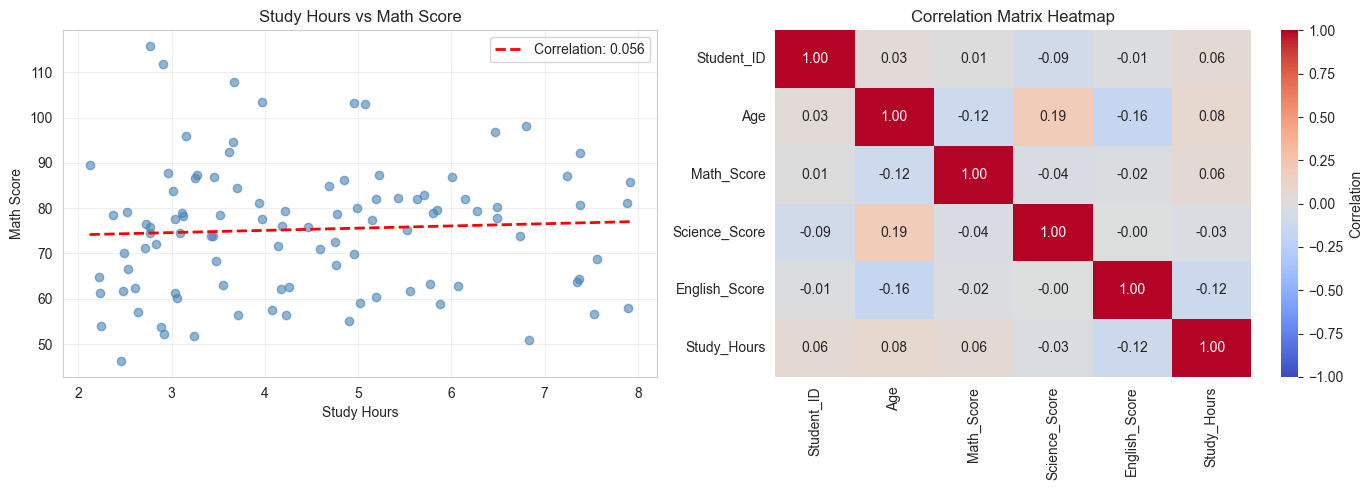

In [16]:
print("\n" + "="*60)
print("COVARIANCE & CORRELATION ANALYSIS")
print("="*60)

# Calculate correlation between Study Hours and Math Score
covariance = df_students['Study_Hours'].cov(df_students['Math_Score'])
correlation = df_students['Study_Hours'].corr(df_students['Math_Score'])

print(f"\nCovariance(Study Hours, Math Score) = {covariance:.4f}")
print(f"Correlation(Study Hours, Math Score) = {correlation:.4f}")

# Interpretation
if correlation > 0.7:
    strength = "Strong positive"
elif correlation > 0.3:
    strength = "Moderate positive"
elif correlation > -0.3:
    strength = "Weak or no"
else:
    strength = "Strong negative"

print(f"\nInterpretation: {strength} relationship")
print(f"As study hours increase, math scores tend to {'increase' if correlation > 0 else 'decrease'}")

# Correlation matrix for all numeric variables
print("\n\nCorrelation Matrix:")
numeric_cols = df_students.select_dtypes(include=[np.number]).columns
corr_matrix = df_students[numeric_cols].corr()
print(corr_matrix.round(3))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
ax1 = axes[0]
ax1.scatter(df_students['Study_Hours'], df_students['Math_Score'], alpha=0.6, color='steelblue')
# Add trend line
z = np.polyfit(df_students['Study_Hours'], df_students['Math_Score'], 1)
p = np.poly1d(z)
ax1.plot(df_students['Study_Hours'].sort_values(), 
         p(df_students['Study_Hours'].sort_values()), 
         "r--", linewidth=2, label=f'Correlation: {correlation:.3f}')
ax1.set_xlabel('Study Hours')
ax1.set_ylabel('Math Score')
ax1.set_title('Study Hours vs Math Score')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Correlation heatmap
ax2 = axes[1]
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            cbar_kws={'label': 'Correlation'}, ax=ax2, vmin=-1, vmax=1)
ax2.set_title('Correlation Matrix Heatmap')

plt.tight_layout()
plt.show()

### Exercise 2.3: Skewness Analysis


SKEWNESS ANALYSIS

Skewness Values:
Math Score:    0.3812
Science Score: 0.1751
English Score: 0.1966

Skewness Interpretation:
  > 0  : Right-skewed (positively skewed) - tail on right
  = 0  : Symmetric distribution
  < 0  : Left-skewed (negatively skewed) - tail on left


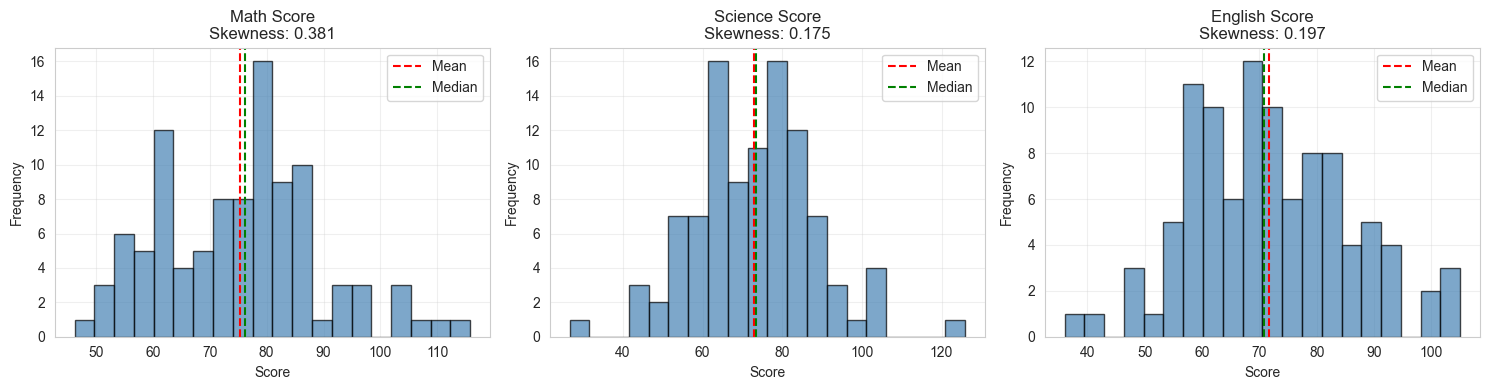

In [17]:
print("\n" + "="*60)
print("SKEWNESS ANALYSIS")
print("="*60)

from scipy.stats import skew, kurtosis

# Calculate skewness for different scores
math_skew = skew(df_students['Math_Score'])
science_skew = skew(df_students['Science_Score'])
english_skew = skew(df_students['English_Score'])

print("\nSkewness Values:")
print(f"Math Score:    {math_skew:.4f}")
print(f"Science Score: {science_skew:.4f}")
print(f"English Score: {english_skew:.4f}")

print("\nSkewness Interpretation:")
print("  > 0  : Right-skewed (positively skewed) - tail on right")
print("  = 0  : Symmetric distribution")
print("  < 0  : Left-skewed (negatively skewed) - tail on left")

# Visualize distributions with different skewness
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

subjects = ['Math_Score', 'Science_Score', 'English_Score']
skewness_vals = [math_skew, science_skew, english_skew]
titles = ['Math Score', 'Science Score', 'English Score']

for idx, (subject, skew_val, title) in enumerate(zip(subjects, skewness_vals, titles)):
    ax = axes[idx]
    ax.hist(df_students[subject], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
    ax.axvline(df_students[subject].mean(), color='red', linestyle='--', label='Mean')
    ax.axvline(df_students[subject].median(), color='green', linestyle='--', label='Median')
    ax.set_xlabel('Score')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{title}\nSkewness: {skew_val:.3f}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Topic 3: Distributions and Their Applications

### Concepts Covered:
- **Types of Probability Distributions**: Binomial, Poisson, Normal, Uniform, Bernoulli
- **Binomial Distribution**: n trials, each with probability p
- **Poisson Distribution**: Events occurring at a constant rate
- **Normal Distribution (Gaussian)**: Bell-shaped, symmetric
- **Probability Density/Mass Functions**
- **Cumulative Density Functions**
- **Examples of Applications**: Bernoulli, Uniform, Normal distributions

### Detailed Explanations:

#### Binomial Distribution B(n,p)
- Number of successes in n independent Bernoulli trials
- P(X = k) = C(n,k) × p^k × (1-p)^(n-k)
- Parameters: n (number of trials), p (probability of success)
- E(X) = np, Var(X) = np(1-p)

#### Poisson Distribution λ
- Number of events in a fixed interval
- P(X = k) = (e^(-λ) × λ^k) / k!
- Parameter: λ (mean number of events)
- E(X) = λ, Var(X) = λ

#### Normal Distribution N(μ,σ²)
- Most important distribution in statistics
- Symmetric, bell-shaped curve
- Parameters: μ (mean), σ (standard deviation)
- Standard Normal: μ=0, σ=1

### Exercise 3.1: Binomial Distribution

In [18]:
print("\n" + "="*60)
print("BINOMIAL DISTRIBUTION")
print("="*60)

print("\nExample: Coin Flip Experiment")
print("-" * 50)
print("Scenario: Flip a fair coin 10 times")
print("Question: What's the probability of getting exactly 7 heads?")

n = 10  # number of trials
p = 0.5  # probability of success (heads)
k = 7    # number of successes

# Calculate probability
prob_exactly_7 = binom.pmf(k, n, p)
print(f"\nP(X = 7) = {prob_exactly_7:.4f}")

# Cumulative probability: at most 7 heads
prob_at_most_7 = binom.cdf(7, n, p)
print(f"P(X ≤ 7) = {prob_at_most_7:.4f}")

# Mean and variance
mean_binomial = n * p
var_binomial = n * p * (1 - p)
std_binomial = np.sqrt(var_binomial)

print(f"\nDistribution Parameters:")
print(f"Expected Value E(X) = np = {mean_binomial:.2f}")
print(f"Variance Var(X) = np(1-p) = {var_binomial:.2f}")
print(f"Standard Deviation σ = {std_binomial:.2f}")

# Probability distribution
k_values = np.arange(0, n+1)
probabilities = binom.pmf(k_values, n, p)

print(f"\nProbability Distribution:")
print("k (heads) | Probability")
for k_val, prob in zip(k_values, probabilities):
    print(f"   {k_val:2d}    |  {prob:.6f}")


BINOMIAL DISTRIBUTION

Example: Coin Flip Experiment
--------------------------------------------------
Scenario: Flip a fair coin 10 times
Question: What's the probability of getting exactly 7 heads?

P(X = 7) = 0.1172
P(X ≤ 7) = 0.9453

Distribution Parameters:
Expected Value E(X) = np = 5.00
Variance Var(X) = np(1-p) = 2.50
Standard Deviation σ = 1.58

Probability Distribution:
k (heads) | Probability
    0    |  0.000977
    1    |  0.009766
    2    |  0.043945
    3    |  0.117187
    4    |  0.205078
    5    |  0.246094
    6    |  0.205078
    7    |  0.117187
    8    |  0.043945
    9    |  0.009766
   10    |  0.000977


### Exercise 3.2: Poisson Distribution

In [40]:
print("\n" + "="*60)
print("POISSON DISTRIBUTION")
print("="*60)

print("\nExample: Customer Arrivals")
print("-" * 50)
print("Scenario: Average 3 customers arrive per hour")
print("Question: What's the probability of exactly 5 arrivals in the next hour?")

lambda_param = 3  # average events per interval
k = 5  # number of events we're interested in

# Calculate probability
prob_exactly_5 = poisson.pmf(k, lambda_param)
print(f"\nP(X = 5 | λ = 3) = {prob_exactly_5:.4f}")

# Cumulative probability
prob_at_most_5 = poisson.cdf(5, lambda_param)
print(f"P(X ≤ 5 | λ = 3) = {prob_at_most_5:.4f}")

# For Poisson, E(X) = Var(X) = λ
print(f"\nDistribution Parameters:")
print(f"Expected Value E(X) = λ = {lambda_param}")
print(f"Variance Var(X) = λ = {lambda_param}")
print(f"Standard Deviation σ = {np.sqrt(lambda_param):.2f}")

# Probability distribution
k_values = np.arange(0, 12)
probabilities = poisson.pmf(k_values, lambda_param)

print(f"\nProbability Distribution:")
print("k (arrivals) | Probability")
for k_val, prob in zip(k_values, probabilities):
    print(f"     {k_val:2d}      |  {prob:.6f}")


POISSON DISTRIBUTION

Example: Customer Arrivals
--------------------------------------------------
Scenario: Average 3 customers arrive per hour
Question: What's the probability of exactly 5 arrivals in the next hour?

P(X = 5 | λ = 3) = 0.1008
P(X ≤ 5 | λ = 3) = 0.9161

Distribution Parameters:
Expected Value E(X) = λ = 3
Variance Var(X) = λ = 3
Standard Deviation σ = 1.73

Probability Distribution:
k (arrivals) | Probability
      0      |  0.049787
      1      |  0.149361
      2      |  0.224042
      3      |  0.224042
      4      |  0.168031
      5      |  0.100819
      6      |  0.050409
      7      |  0.021604
      8      |  0.008102
      9      |  0.002701
     10      |  0.000810
     11      |  0.000221


### Exercise 3.3: Normal Distribution

In [20]:
print("\n" + "="*60)
print("NORMAL (GAUSSIAN) DISTRIBUTION")
print("="*60)

# Using actual student data
mu = df_students['Math_Score'].mean()
sigma = df_students['Math_Score'].std()

print(f"\nMath Scores follow approximately Normal Distribution")
print(f"Parameters: μ = {mu:.2f}, σ = {sigma:.2f}")

# Probabilities
x = 80
prob_less_than_80 = norm.cdf(x, mu, sigma)
prob_greater_than_80 = 1 - prob_less_than_80
prob_between_70_80 = norm.cdf(80, mu, sigma) - norm.cdf(70, mu, sigma)

print(f"\nProbability Calculations:")
print(f"P(X < 80) = {prob_less_than_80:.4f}")
print(f"P(X > 80) = {prob_greater_than_80:.4f}")
print(f"P(70 < X < 80) = {prob_between_70_80:.4f}")

# Empirical Rule (68-95-99.7)
print(f"\nEmpirical Rule:")
within_1std = norm.cdf(mu + sigma, mu, sigma) - norm.cdf(mu - sigma, mu, sigma)
within_2std = norm.cdf(mu + 2*sigma, mu, sigma) - norm.cdf(mu - 2*sigma, mu, sigma)
within_3std = norm.cdf(mu + 3*sigma, mu, sigma) - norm.cdf(mu - 3*sigma, mu, sigma)

print(f"Within ±1σ: {within_1std:.1%} (theoretical: 68%)")
print(f"Within ±2σ: {within_2std:.1%} (theoretical: 95%)")
print(f"Within ±3σ: {within_3std:.1%} (theoretical: 99.7%)")

# Z-score
z_score = (80 - mu) / sigma
print(f"\nZ-Score for X = 80:")
print(f"Z = (80 - {mu:.2f}) / {sigma:.2f} = {z_score:.4f}")
print(f"This means 80 is {abs(z_score):.2f} standard deviations {'above' if z_score > 0 else 'below'} the mean")


NORMAL (GAUSSIAN) DISTRIBUTION

Math Scores follow approximately Normal Distribution
Parameters: μ = 75.33, σ = 14.31

Probability Calculations:
P(X < 80) = 0.6278
P(X > 80) = 0.3722
P(70 < X < 80) = 0.2732

Empirical Rule:
Within ±1σ: 68.3% (theoretical: 68%)
Within ±2σ: 95.4% (theoretical: 95%)
Within ±3σ: 99.7% (theoretical: 99.7%)

Z-Score for X = 80:
Z = (80 - 75.33) / 14.31 = 0.3261
This means 80 is 0.33 standard deviations above the mean


### Exercise 3.4: Visualize Distributions

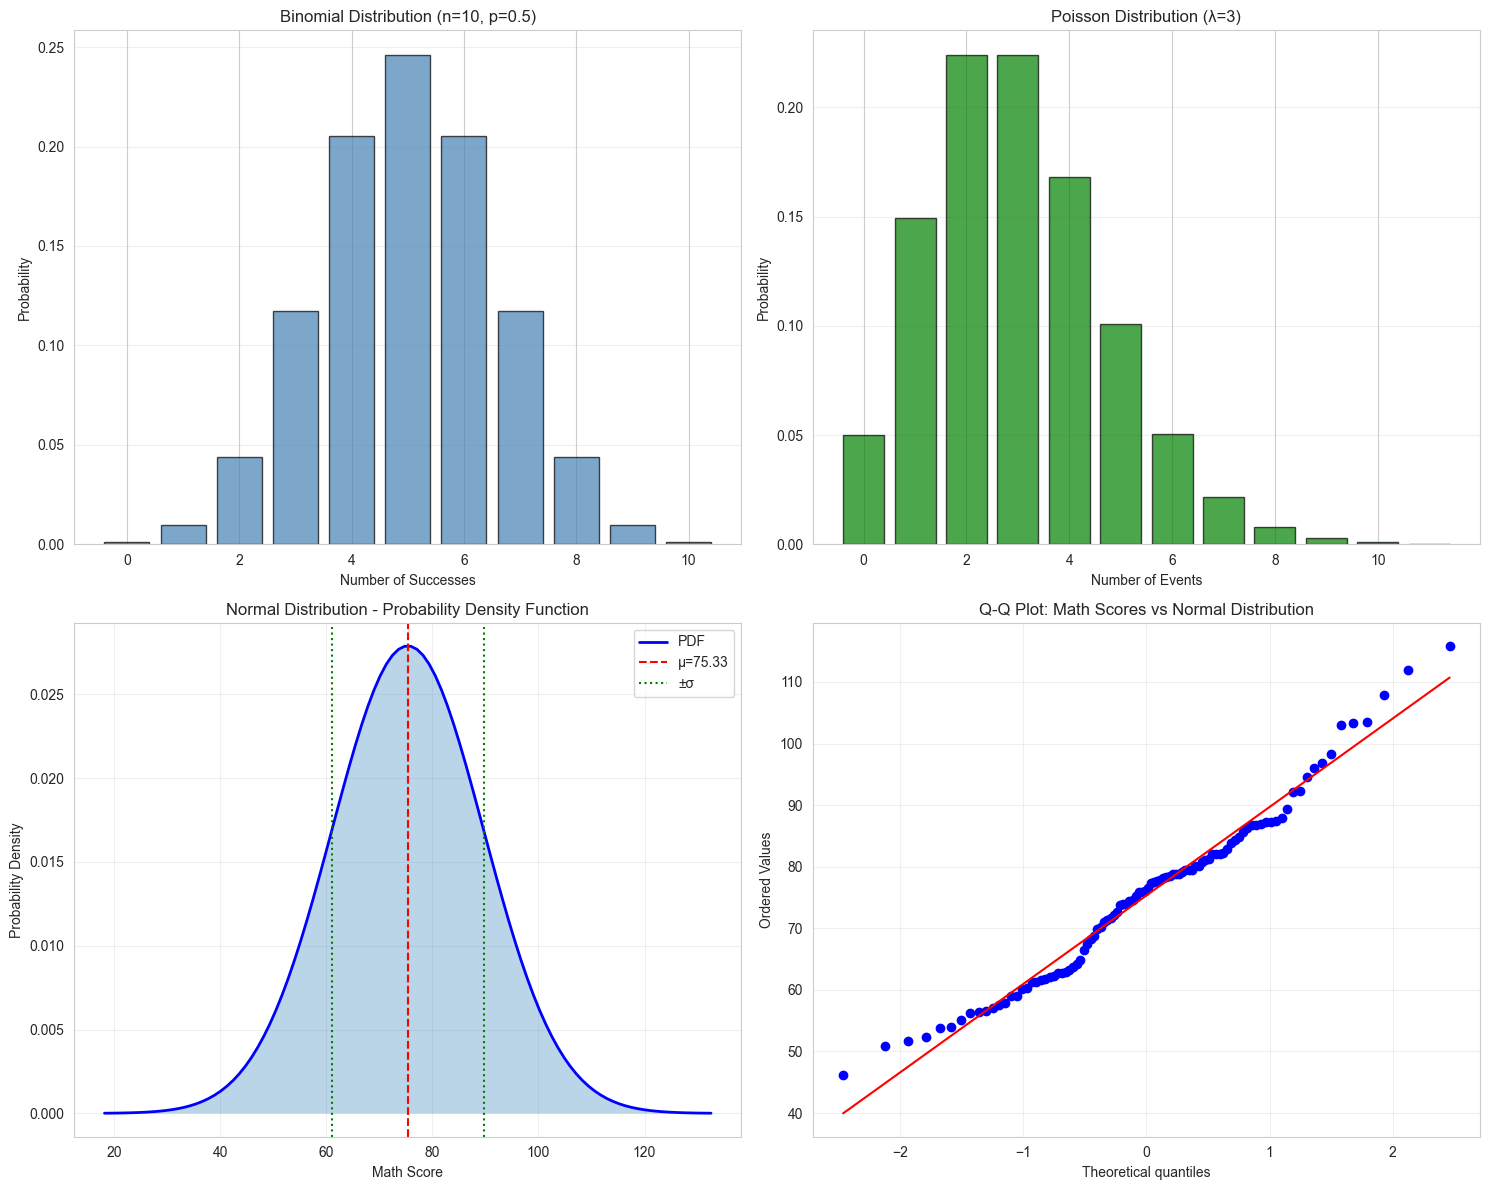

Distribution visualizations complete!


In [21]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Binomial Distribution
ax1 = axes[0, 0]
k_vals = np.arange(0, 11)
binom_probs = binom.pmf(k_vals, 10, 0.5)
ax1.bar(k_vals, binom_probs, color='steelblue', edgecolor='black', alpha=0.7)
ax1.set_xlabel('Number of Successes')
ax1.set_ylabel('Probability')
ax1.set_title('Binomial Distribution (n=10, p=0.5)')
ax1.grid(True, alpha=0.3, axis='y')

# Poisson Distribution
ax2 = axes[0, 1]
k_vals = np.arange(0, 12)
poisson_probs = poisson.pmf(k_vals, 3)
ax2.bar(k_vals, poisson_probs, color='green', edgecolor='black', alpha=0.7)
ax2.set_xlabel('Number of Events')
ax2.set_ylabel('Probability')
ax2.set_title('Poisson Distribution (λ=3)')
ax2.grid(True, alpha=0.3, axis='y')

# Normal Distribution - PDF
ax3 = axes[1, 0]
x_vals = np.linspace(mu - 4*sigma, mu + 4*sigma, 100)
normal_pdf = norm.pdf(x_vals, mu, sigma)
ax3.plot(x_vals, normal_pdf, 'b-', linewidth=2, label='PDF')
ax3.fill_between(x_vals, normal_pdf, alpha=0.3)
ax3.axvline(mu, color='red', linestyle='--', label=f'μ={mu:.2f}')
ax3.axvline(mu-sigma, color='green', linestyle=':', label=f'±σ')
ax3.axvline(mu+sigma, color='green', linestyle=':')
ax3.set_xlabel('Math Score')
ax3.set_ylabel('Probability Density')
ax3.set_title('Normal Distribution - Probability Density Function')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Q-Q Plot
ax4 = axes[1, 1]
stats.probplot(df_students['Math_Score'], dist="norm", plot=ax4)
ax4.set_title('Q-Q Plot: Math Scores vs Normal Distribution')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Distribution visualizations complete!")

---
## Topic 4: Statistical Inference

### Concepts Covered:
- **Z-Statistics**: Standardized test statistic (σ known)
- **Central Limit Theorem**: Distribution of sample means
- **Estimation**: Point estimates and interval estimates
- **Hypothesis Testing**: Null and alternative hypotheses
- **Confidence Intervals**: Range of plausible values for parameters

### Detailed Explanations:

#### Central Limit Theorem
The distribution of sample means approaches a normal distribution as the sample size increases, regardless of the population distribution.
- Sample mean follows N(μ, σ²/n)
- Standard error = σ/√n

#### Hypothesis Testing
- **Null Hypothesis (H₀)**: Status quo or no effect
- **Alternative Hypothesis (H₁)**: What we're trying to prove
- **Test Statistic**: Measure of evidence against H₀
- **P-value**: Probability of observing test statistic if H₀ is true
- **Significance Level (α)**: Threshold for rejecting H₀ (usually 0.05)

#### Confidence Intervals
Range of values likely to contain the true population parameter
- Formula: Point Estimate ± (Critical Value × Standard Error)
- 95% CI: ±1.96 × SE (for normal distribution)

### Exercise 4.1: Central Limit Theorem Demonstration


CENTRAL LIMIT THEOREM DEMONSTRATION
Sample Size n = 10
  Mean of sample means: 1.9396
  Std Dev of sample means: 0.6281
  Theoretical SE = σ/√n: 0.6147

Sample Size n = 30
  Mean of sample means: 1.9494
  Std Dev of sample means: 0.3552
  Theoretical SE = σ/√n: 0.3549

Sample Size n = 100
  Mean of sample means: 1.9560
  Std Dev of sample means: 0.1925
  Theoretical SE = σ/√n: 0.1944

Sample Size n = 500
  Mean of sample means: 1.9558
  Std Dev of sample means: 0.0857
  Theoretical SE = σ/√n: 0.0869



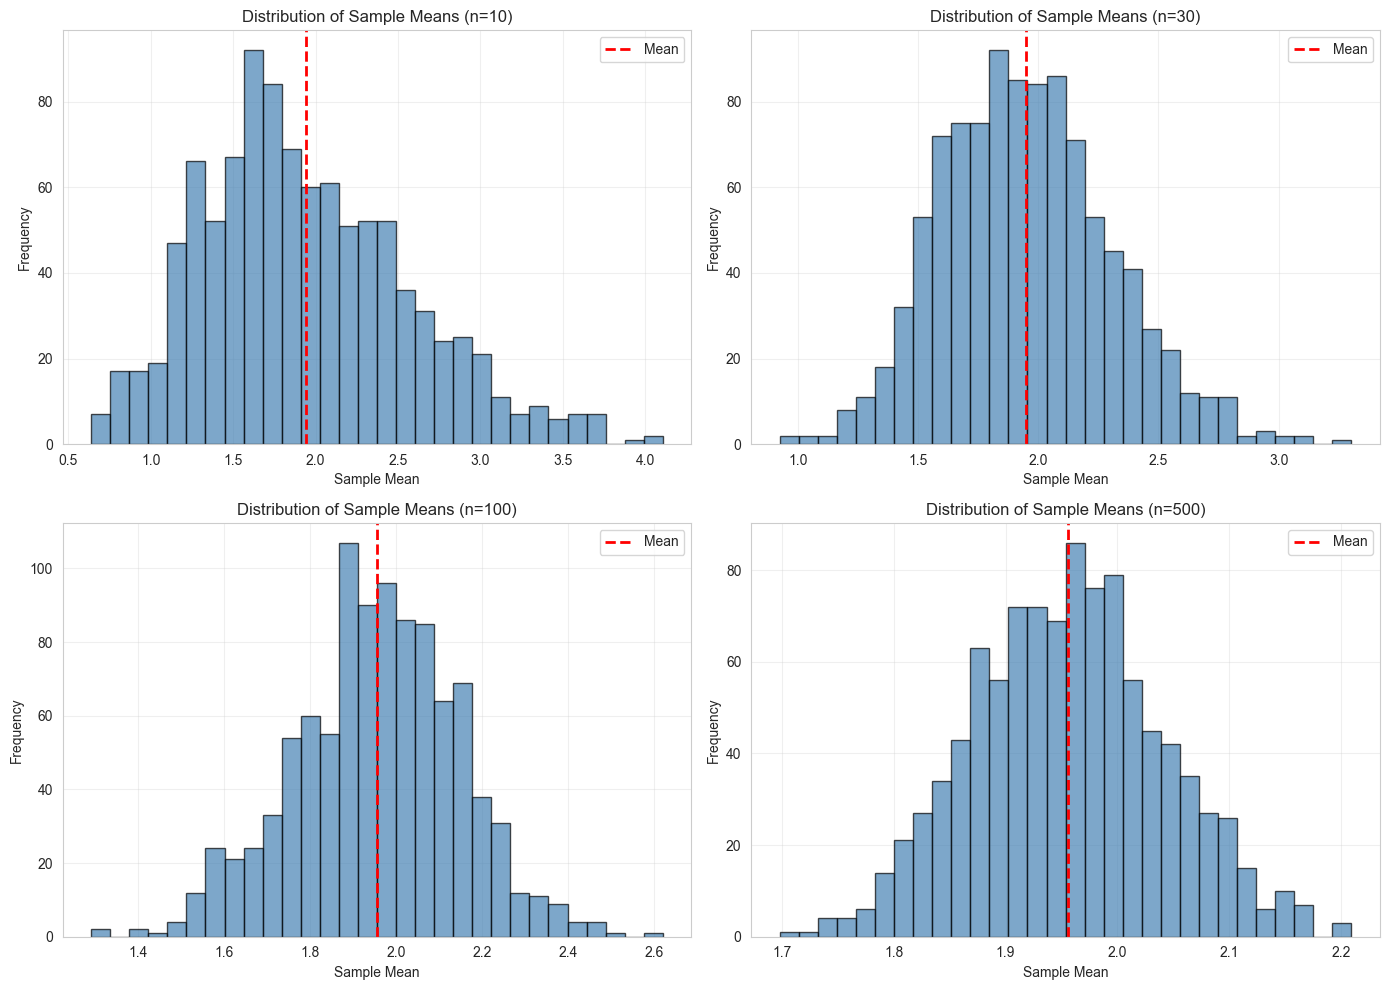

As sample size increases, distribution of sample means becomes more normal!


In [22]:
print("\n" + "="*60)
print("CENTRAL LIMIT THEOREM DEMONSTRATION")
print("="*60)

# Demonstrate CLT with different sample sizes
population = np.random.exponential(scale=2, size=10000)  # Non-normal population

sample_sizes = [10, 30, 100, 500]
num_samples = 1000

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, n in enumerate(sample_sizes):
    # Take multiple samples and calculate their means
    sample_means = [np.mean(np.random.choice(population, size=n)) for _ in range(num_samples)]
    
    ax = axes[idx]
    ax.hist(sample_means, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    ax.axvline(np.mean(sample_means), color='red', linestyle='--', linewidth=2, label='Mean')
    ax.set_xlabel('Sample Mean')
    ax.set_ylabel('Frequency')
    ax.set_title(f'Distribution of Sample Means (n={n})')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    print(f"Sample Size n = {n}")
    print(f"  Mean of sample means: {np.mean(sample_means):.4f}")
    print(f"  Std Dev of sample means: {np.std(sample_means):.4f}")
    print(f"  Theoretical SE = σ/√n: {np.std(population)/np.sqrt(n):.4f}")
    print()

plt.tight_layout()
plt.show()

print("As sample size increases, distribution of sample means becomes more normal!")

### Exercise 4.2: Confidence Intervals

In [23]:
print("\n" + "="*60)
print("CONFIDENCE INTERVALS")
print("="*60)

# Calculate 95% Confidence Interval for mean Math Score
sample_mean = df_students['Math_Score'].mean()
sample_std = df_students['Math_Score'].std()
n = len(df_students)
standard_error = sample_std / np.sqrt(n)
confidence_level = 0.95
alpha = 1 - confidence_level

# Critical value (using t-distribution for sample)
t_critical = t.ppf(1 - alpha/2, df=n-1)

# Margin of error
margin_of_error = t_critical * standard_error

# Confidence interval
ci_lower = sample_mean - margin_of_error
ci_upper = sample_mean + margin_of_error

print(f"\n95% Confidence Interval for Mean Math Score")
print("="*50)
print(f"Sample Mean:        {sample_mean:.4f}")
print(f"Standard Deviation: {sample_std:.4f}")
print(f"Standard Error:     {standard_error:.4f}")
print(f"t-critical value:   {t_critical:.4f}")
print(f"Margin of Error:    {margin_of_error:.4f}")
print(f"\n95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"\nInterpretation: We are 95% confident that the true population mean")
print(f"math score lies between {ci_lower:.2f} and {ci_upper:.2f}")

# Different confidence levels
print("\n" + "-"*50)
print("Confidence Intervals at Different Levels:")
print("-"*50)

for conf in [0.90, 0.95, 0.99]:
    alpha = 1 - conf
    t_crit = t.ppf(1 - alpha/2, df=n-1)
    me = t_crit * standard_error
    lower = sample_mean - me
    upper = sample_mean + me
    print(f"\n{int(conf*100)}% CI: [{lower:.2f}, {upper:.2f}]")
    print(f"  Width: {upper-lower:.2f} (Margin of Error: {me:.2f})")


CONFIDENCE INTERVALS

95% Confidence Interval for Mean Math Score
Sample Mean:        75.3346
Standard Deviation: 14.3050
Standard Error:     1.4305
t-critical value:   1.9842
Margin of Error:    2.8384

95% CI: [72.4961, 78.1730]

Interpretation: We are 95% confident that the true population mean
math score lies between 72.50 and 78.17

--------------------------------------------------
Confidence Intervals at Different Levels:
--------------------------------------------------

90% CI: [72.96, 77.71]
  Width: 4.75 (Margin of Error: 2.38)

95% CI: [72.50, 78.17]
  Width: 5.68 (Margin of Error: 2.84)

99% CI: [71.58, 79.09]
  Width: 7.51 (Margin of Error: 3.76)


### Exercise 4.3: One-Sample Z-Test

In [24]:
print("\n" + "="*60)
print("ONE-SAMPLE Z-TEST")
print("="*60)

# Hypothesis: Is the mean math score significantly different from 75?
hypothesized_mean = 75
sample_mean = df_students['Math_Score'].mean()
sample_std = df_students['Math_Score'].std()
n = len(df_students)

print(f"\nHypothesis Test Setup:")
print(f"H₀ (Null):      μ = {hypothesized_mean}")
print(f"H₁ (Alternative): μ ≠ {hypothesized_mean} (Two-tailed)")
print(f"Significance level: α = 0.05")
print(f"\nSample Statistics:")
print(f"Sample Mean:    {sample_mean:.4f}")
print(f"Sample Std Dev: {sample_std:.4f}")
print(f"Sample Size:    {n}")

# Calculate test statistic
standard_error = sample_std / np.sqrt(n)
z_statistic = (sample_mean - hypothesized_mean) / standard_error

# P-value (two-tailed)
p_value = 2 * (1 - norm.cdf(abs(z_statistic)))

print(f"\nTest Statistic:")
print(f"Standard Error: {standard_error:.4f}")
print(f"Z-statistic:    {z_statistic:.4f}")
print(f"P-value:        {p_value:.6f}")

print(f"\nConclusion:")
if p_value < 0.05:
    print(f"P-value ({p_value:.6f}) < 0.05")
    print(f"REJECT the null hypothesis.")
    print(f"The mean math score is significantly different from {hypothesized_mean}.")
else:
    print(f"P-value ({p_value:.6f}) >= 0.05")
    print(f"FAIL TO REJECT the null hypothesis.")
    print(f"The mean math score is not significantly different from {hypothesized_mean}.")


ONE-SAMPLE Z-TEST

Hypothesis Test Setup:
H₀ (Null):      μ = 75
H₁ (Alternative): μ ≠ 75 (Two-tailed)
Significance level: α = 0.05

Sample Statistics:
Sample Mean:    75.3346
Sample Std Dev: 14.3050
Sample Size:    100

Test Statistic:
Standard Error: 1.4305
Z-statistic:    0.2339
P-value:        0.815077

Conclusion:
P-value (0.815077) >= 0.05
FAIL TO REJECT the null hypothesis.
The mean math score is not significantly different from 75.


---
## Module 9: Advanced Statistical Inference

## Topic 1: Hypothesis Testing and Errors

### Concepts Covered:
- **Hypothesis Testing Mechanism**: Structure and decision rules
- **Type I Error (α)**: Rejecting true null hypothesis (False Positive)
- **Type II Error (β)**: Failing to reject false null hypothesis (False Negative)
- **T-Tests vs Z-Tests**: When to use each test
- **Statistical Power**: 1 - β, probability of correctly rejecting false H₀

### Detailed Explanations:

#### Error Types in Hypothesis Testing
| | H₀ is True | H₀ is False |
|---|---|---|
| Reject H₀ | Type I Error (α) | Correct ✓ |
| Fail to Reject H₀ | Correct ✓ | Type II Error (β) |

#### T-Test vs Z-Test
- **Z-Test**: Use when population σ is known or n is very large (n > 30)
- **T-Test**: Use when population σ is unknown and n is small
- T-distribution has heavier tails than normal distribution
- As df increases, t-distribution approaches normal distribution

### Exercise 5.1: Hypothesis Testing - Type I and Type II Errors

In [25]:
print("\n" + "="*60)
print("HYPOTHESIS TESTING: TYPE I AND TYPE II ERRORS")
print("="*60)

print("\nExample: Medical Test for Disease")
print("-"*50)
print("Null Hypothesis (H₀): Person does NOT have disease")
print("Alternative (H₁):     Person HAS disease")
print()

print("Decision Matrix:")
print()
decision_matrix = pd.DataFrame({
    'Decision': ['Reject H₀ (Test Positive)', 'Fail to Reject H₀ (Test Negative)'],
    'H₀ True (No Disease)': ['Type I Error (α) - False Positive', 'Correct - True Negative'],
    'H₀ False (Has Disease)': ['Correct - True Positive', 'Type II Error (β) - False Negative']
})

print(decision_matrix.to_string(index=False))

print("\n" + "="*50)
print("Implications:")
print("="*50)
print("Type I Error (α): Claiming someone has disease when they don't")
print("  - Causes unnecessary treatment")
print("  - Typically set at 0.05 (5% risk)")
print()
print("Type II Error (β): Missing someone who actually has disease")
print("  - Dangerous, disease goes untreated")
print("  - Power = 1 - β (should be high, e.g., 0.80)")


HYPOTHESIS TESTING: TYPE I AND TYPE II ERRORS

Example: Medical Test for Disease
--------------------------------------------------
Null Hypothesis (H₀): Person does NOT have disease
Alternative (H₁):     Person HAS disease

Decision Matrix:

                         Decision              H₀ True (No Disease)             H₀ False (Has Disease)
        Reject H₀ (Test Positive) Type I Error (α) - False Positive            Correct - True Positive
Fail to Reject H₀ (Test Negative)           Correct - True Negative Type II Error (β) - False Negative

Implications:
Type I Error (α): Claiming someone has disease when they don't
  - Causes unnecessary treatment
  - Typically set at 0.05 (5% risk)

Type II Error (β): Missing someone who actually has disease
  - Dangerous, disease goes untreated
  - Power = 1 - β (should be high, e.g., 0.80)


### Exercise 5.2: Independent Samples T-Test

In [26]:
print("\n" + "="*60)
print("INDEPENDENT SAMPLES T-TEST")
print("="*60)

# Compare math scores between Male and Female students
male_scores = df_students[df_students['Gender'] == 'Male']['Math_Score']
female_scores = df_students[df_students['Gender'] == 'Female']['Math_Score']

print(f"\nQuestion: Is there a significant difference in math scores between genders?")
print(f"\nH₀: μ_male = μ_female (No difference)")
print(f"H₁: μ_male ≠ μ_female (Difference exists)")
print(f"Significance level: α = 0.05")

print(f"\nDescriptive Statistics:")
print(f"Males:   n={len(male_scores)}, Mean={male_scores.mean():.2f}, SD={male_scores.std():.2f}")
print(f"Females: n={len(female_scores)}, Mean={female_scores.mean():.2f}, SD={female_scores.std():.2f}")

# Perform independent samples t-test
t_stat, p_value = stats.ttest_ind(male_scores, female_scores)

print(f"\nT-Test Results:")
print(f"T-statistic:  {t_stat:.4f}")
print(f"P-value:      {p_value:.6f}")
print(f"\nConclusion:")
if p_value < 0.05:
    print(f"P-value < 0.05: REJECT null hypothesis")
    print(f"There IS a significant difference in math scores between genders.")
else:
    print(f"P-value >= 0.05: FAIL TO REJECT null hypothesis")
    print(f"There is NO significant difference in math scores between genders.")


INDEPENDENT SAMPLES T-TEST

Question: Is there a significant difference in math scores between genders?

H₀: μ_male = μ_female (No difference)
H₁: μ_male ≠ μ_female (Difference exists)
Significance level: α = 0.05

Descriptive Statistics:
Males:   n=55, Mean=73.14, SD=14.40
Females: n=45, Mean=78.02, SD=13.87

T-Test Results:
T-statistic:  -1.7154
P-value:      0.089423

Conclusion:
P-value >= 0.05: FAIL TO REJECT null hypothesis
There is NO significant difference in math scores between genders.


### Exercise 5.3: T-Distribution vs Normal Distribution

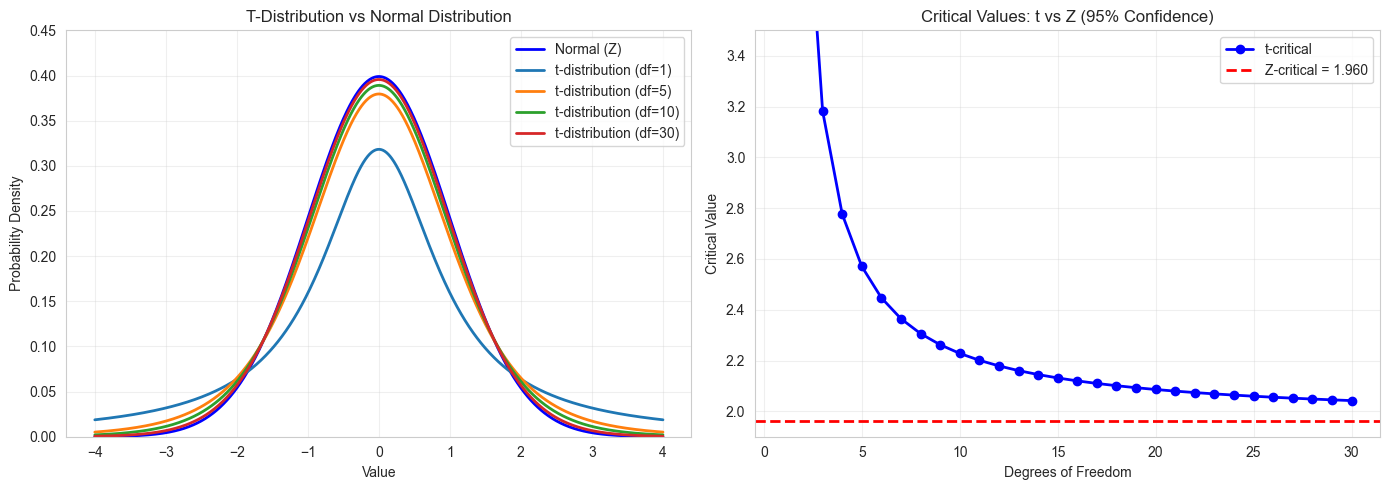

T-distribution has heavier tails (more extreme values)
As df increases, t-distribution approaches normal distribution


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# T-distribution with different degrees of freedom
ax1 = axes[0]
x = np.linspace(-4, 4, 1000)

# Plot normal distribution
normal_dist = norm.pdf(x)
ax1.plot(x, normal_dist, 'b-', linewidth=2, label='Normal (Z)')

# Plot t-distributions with different df
for df in [1, 5, 10, 30]:
    t_dist = t.pdf(x, df)
    ax1.plot(x, t_dist, linewidth=2, label=f't-distribution (df={df})')

ax1.set_xlabel('Value')
ax1.set_ylabel('Probability Density')
ax1.set_title('T-Distribution vs Normal Distribution')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0, 0.45])

# Critical values comparison
ax2 = axes[1]
df_values = np.arange(1, 31)
t_critical_values = [t.ppf(0.975, df) for df in df_values]  # 95% CI
z_critical = norm.ppf(0.975)

ax2.plot(df_values, t_critical_values, 'b-', linewidth=2, marker='o', label='t-critical')
ax2.axhline(z_critical, color='red', linestyle='--', linewidth=2, label=f'Z-critical = {z_critical:.3f}')
ax2.set_xlabel('Degrees of Freedom')
ax2.set_ylabel('Critical Value')
ax2.set_title('Critical Values: t vs Z (95% Confidence)')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim([1.9, 3.5])

plt.tight_layout()
plt.show()

print("T-distribution has heavier tails (more extreme values)")
print("As df increases, t-distribution approaches normal distribution")

---
## Topic 2: Statistical Distributions and Tests

### Concepts Covered:
- **Chi-Square Test**: Test for independence and goodness of fit
- **T-Statistics**: Test statistic for t-tests
- **Chi-Square Distribution**: Properties and applications
- **Student T Distribution**: For small samples
- **Goodness of Fit**: How well data matches expected distribution

### Detailed Explanations:

#### Chi-Square Test
Tests whether observed frequencies differ significantly from expected frequencies.
- **Goodness of Fit**: Test if data follows expected distribution
- **Test of Independence**: Test relationship between categorical variables
- χ² = Σ((Observed - Expected)² / Expected)
- Degrees of freedom = number of categories - 1

#### Chi-Square Distribution
- Always positive, right-skewed
- Shape determined by degrees of freedom
- Used for testing variance and categorical data

### Exercise 6.1: Chi-Square Goodness of Fit Test

In [28]:
print("\n" + "="*60)
print("CHI-SQUARE GOODNESS OF FIT TEST")
print("="*60)

print("\nExample: Fair Die Test")
print("-"*50)
print("Question: Is this die fair?")
print("We rolled it 600 times.")

# Observed frequencies
observed = np.array([95, 92, 105, 98, 107, 103])
expected = np.array([100, 100, 100, 100, 100, 100])  # Fair die expectation

print(f"\nObserved: {observed}")
print(f"Expected: {expected}")

# Chi-square test
chi2_stat, p_value = stats.chisquare(observed, expected)

print(f"\nHypothesis Test:")
print(f"H₀: Die is fair (observed = expected)")
print(f"H₁: Die is not fair (observed ≠ expected)")
print(f"\nTest Results:")
print(f"Chi-square statistic: {chi2_stat:.4f}")
print(f"P-value:              {p_value:.6f}")
print(f"Degrees of freedom:   {len(observed) - 1}")

print(f"\nConclusion:")
if p_value < 0.05:
    print(f"P-value < 0.05: REJECT null hypothesis")
    print(f"The die is NOT fair.")
else:
    print(f"P-value >= 0.05: FAIL TO REJECT null hypothesis")
    print(f"The die appears to be fair.")

# Contribution to chi-square
print(f"\nContribution to χ²:")
contributions = (observed - expected)**2 / expected
for face, obs, exp, contrib in zip(range(1, 7), observed, expected, contributions):
    print(f"Face {face}: ({obs} - {exp})²/{exp} = {contrib:.4f}")


CHI-SQUARE GOODNESS OF FIT TEST

Example: Fair Die Test
--------------------------------------------------
Question: Is this die fair?
We rolled it 600 times.

Observed: [ 95  92 105  98 107 103]
Expected: [100 100 100 100 100 100]

Hypothesis Test:
H₀: Die is fair (observed = expected)
H₁: Die is not fair (observed ≠ expected)

Test Results:
Chi-square statistic: 1.7600
P-value:              0.881256
Degrees of freedom:   5

Conclusion:
P-value >= 0.05: FAIL TO REJECT null hypothesis
The die appears to be fair.

Contribution to χ²:
Face 1: (95 - 100)²/100 = 0.2500
Face 2: (92 - 100)²/100 = 0.6400
Face 3: (105 - 100)²/100 = 0.2500
Face 4: (98 - 100)²/100 = 0.0400
Face 5: (107 - 100)²/100 = 0.4900
Face 6: (103 - 100)²/100 = 0.0900


### Exercise 6.2: Chi-Square Test of Independence

In [29]:
print("\n" + "="*60)
print("CHI-SQUARE TEST OF INDEPENDENCE")
print("="*60)

# Create contingency table: Gender vs Pass/Fail
# Assume students with score >= 70 pass
df_students['Pass_Fail'] = df_students['Math_Score'].apply(lambda x: 'Pass' if x >= 70 else 'Fail')

contingency_table = pd.crosstab(df_students['Gender'], df_students['Pass_Fail'])

print("\nQuestion: Is there a relationship between gender and passing the exam?")
print(f"\nContingency Table:")
print(contingency_table)

# Add row and column totals
contingency_with_totals = contingency_table.copy()
contingency_with_totals['Total'] = contingency_with_totals.sum(axis=1)
contingency_with_totals.loc['Total'] = contingency_with_totals.sum()

print(f"\nWith Totals:")
print(contingency_with_totals)

# Chi-square test
chi2_stat, p_value, dof, expected_freq = stats.chi2_contingency(contingency_table)

print(f"\nHypothesis Test:")
print(f"H₀: Gender and pass/fail are independent")
print(f"H₁: Gender and pass/fail are not independent")

print(f"\nTest Results:")
print(f"Chi-square statistic: {chi2_stat:.4f}")
print(f"P-value:              {p_value:.6f}")
print(f"Degrees of freedom:   {dof}")

print(f"\nExpected Frequencies:")
expected_df = pd.DataFrame(expected_freq, 
                           index=contingency_table.index,
                           columns=contingency_table.columns)
print(expected_df.round(2))

print(f"\nConclusion:")
if p_value < 0.05:
    print(f"P-value < 0.05: REJECT null hypothesis")
    print(f"Gender and passing are NOT independent (relationship exists).")
else:
    print(f"P-value >= 0.05: FAIL TO REJECT null hypothesis")
    print(f"Gender and passing are independent (no relationship).")


CHI-SQUARE TEST OF INDEPENDENCE

Question: Is there a relationship between gender and passing the exam?

Contingency Table:
Pass_Fail  Fail  Pass
Gender               
Female       11    34
Male         24    31

With Totals:
Pass_Fail  Fail  Pass  Total
Gender                      
Female       11    34     45
Male         24    31     55
Total        35    65    100

Hypothesis Test:
H₀: Gender and pass/fail are independent
H₁: Gender and pass/fail are not independent

Test Results:
Chi-square statistic: 3.2079
P-value:              0.073283
Degrees of freedom:   1

Expected Frequencies:
Pass_Fail   Fail   Pass
Gender                 
Female     15.75  29.25
Male       19.25  35.75

Conclusion:
P-value >= 0.05: FAIL TO REJECT null hypothesis
Gender and passing are independent (no relationship).


### Exercise 6.3: Visualize Chi-Square Distribution

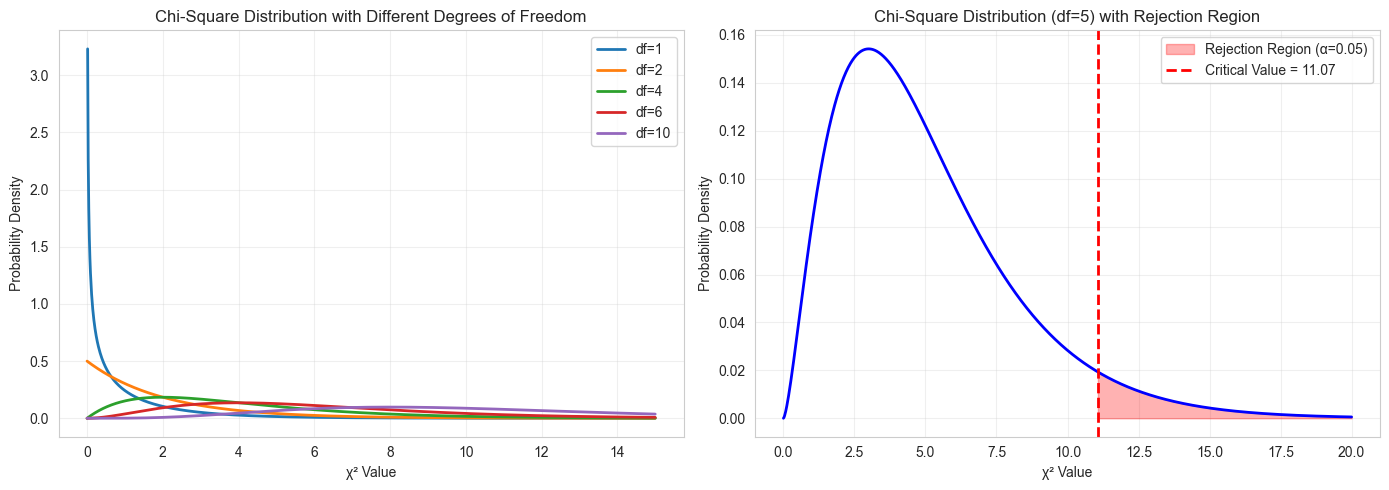

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chi-square distribution with different df
ax1 = axes[0]
x = np.linspace(0, 15, 1000)

for df in [1, 2, 4, 6, 10]:
    chi2_dist = chi2.pdf(x, df)
    ax1.plot(x, chi2_dist, linewidth=2, label=f'df={df}')

ax1.set_xlabel('χ² Value')
ax1.set_ylabel('Probability Density')
ax1.set_title('Chi-Square Distribution with Different Degrees of Freedom')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Critical region for df=5, α=0.05
ax2 = axes[1]
df = 5
x = np.linspace(0, 20, 1000)
chi2_dist = chi2.pdf(x, df)
ax2.plot(x, chi2_dist, 'b-', linewidth=2)

# Critical value
critical_value = chi2.ppf(0.95, df)
x_crit = np.linspace(critical_value, 20, 100)
ax2.fill_between(x_crit, chi2.pdf(x_crit, df), alpha=0.3, color='red', label='Rejection Region (α=0.05)')
ax2.axvline(critical_value, color='red', linestyle='--', linewidth=2, label=f'Critical Value = {critical_value:.2f}')

ax2.set_xlabel('χ² Value')
ax2.set_ylabel('Probability Density')
ax2.set_title(f'Chi-Square Distribution (df={df}) with Rejection Region')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Topic 3: Bayesian Statistics and Confidence Intervals

### Concepts Covered:
- **Bayes' Theorem**: P(A|B) = P(B|A) × P(A) / P(B)
- **Bayes Statistics**: Incorporating prior beliefs
- **Confidence Intervals (CI)**: Range of plausible parameter values
- **Confidence Levels**: 90%, 95%, 99%
- **Interpretation**: What CI means and doesn't mean
- **Confidence Intervals and Margin of Error**

### Detailed Explanations:

#### Bayes' Theorem
Relates conditional probabilities:
P(A|B) = P(B|A) × P(A) / P(B)

Where:
- P(A|B) = Posterior probability
- P(B|A) = Likelihood
- P(A) = Prior probability
- P(B) = Evidence (marginal probability)

#### Confidence Interval Interpretation
- A 95% CI means if we repeated the experiment many times, ~95% of CIs would contain the true parameter
- NOT: 95% probability the parameter is in this specific interval
- Wider intervals = less precise estimate but more confidence
- Narrower intervals = more precise but less confidence

### Exercise 7.1: Bayes' Theorem Application

In [31]:
print("\n" + "="*60)
print("BAYES' THEOREM APPLICATION")
print("="*60)

print("\nExample: Medical Test")
print("-"*50)
print("Given Information:")
print("  - Disease prevalence: 1% (P(Disease) = 0.01)")
print("  - Test sensitivity: 99% (P(+|Disease) = 0.99)")
print("  - Test specificity: 99% (P(-|No Disease) = 0.99)")
print("\nQuestion: If test is positive, what's probability of having disease?")

# Given probabilities
P_disease = 0.01
P_no_disease = 0.99
P_positive_given_disease = 0.99  # Sensitivity
P_negative_given_no_disease = 0.99  # Specificity
P_positive_given_no_disease = 1 - P_negative_given_no_disease  # False positive rate

# Apply Bayes' theorem
# P(Disease | +) = P(+|Disease) × P(Disease) / P(+)

# Calculate P(+)
P_positive = (P_positive_given_disease * P_disease + 
              P_positive_given_no_disease * P_no_disease)

# Calculate P(Disease | +)
P_disease_given_positive = (P_positive_given_disease * P_disease) / P_positive

print(f"\nStep-by-step Calculation:")
print(f"\n1. P(+ | Disease) = {P_positive_given_disease}")
print(f"2. P(Disease) = {P_disease}")
print(f"3. P(+ | No Disease) = {P_positive_given_no_disease}")
print(f"4. P(No Disease) = {P_no_disease}")
print(f"\n5. P(+) = P(+|Disease)×P(Disease) + P(+|¬Disease)×P(¬Disease)")
print(f"   P(+) = {P_positive_given_disease}×{P_disease} + {P_positive_given_no_disease}×{P_no_disease}")
print(f"   P(+) = {P_positive:.6f}")
print(f"\n6. P(Disease|+) = P(+|Disease) × P(Disease) / P(+)")
print(f"   P(Disease|+) = {P_positive_given_disease} × {P_disease} / {P_positive:.6f}")
print(f"   P(Disease|+) = {P_disease_given_positive:.4f} or {P_disease_given_positive*100:.2f}%")

print(f"\nInterpretation:")
print(f"Even though the test is 99% accurate, if it's positive,")
print(f"there's only about {P_disease_given_positive*100:.2f}% chance you actually have the disease!")
print(f"\nReason: Disease is very rare, so false positives dominate.")


BAYES' THEOREM APPLICATION

Example: Medical Test
--------------------------------------------------
Given Information:
  - Disease prevalence: 1% (P(Disease) = 0.01)
  - Test sensitivity: 99% (P(+|Disease) = 0.99)
  - Test specificity: 99% (P(-|No Disease) = 0.99)

Question: If test is positive, what's probability of having disease?

Step-by-step Calculation:

1. P(+ | Disease) = 0.99
2. P(Disease) = 0.01
3. P(+ | No Disease) = 0.010000000000000009
4. P(No Disease) = 0.99

5. P(+) = P(+|Disease)×P(Disease) + P(+|¬Disease)×P(¬Disease)
   P(+) = 0.99×0.01 + 0.010000000000000009×0.99
   P(+) = 0.019800

6. P(Disease|+) = P(+|Disease) × P(Disease) / P(+)
   P(Disease|+) = 0.99 × 0.01 / 0.019800
   P(Disease|+) = 0.5000 or 50.00%

Interpretation:
Even though the test is 99% accurate, if it's positive,
there's only about 50.00% chance you actually have the disease!

Reason: Disease is very rare, so false positives dominate.


### Exercise 7.2: Interpreting Confidence Intervals


INTERPRETING CONFIDENCE INTERVALS

Simulation: Drawing 100 samples of size 30
True population mean: 75
Confidence level: 95.0%

Results:
Number of CIs containing true mean: 95/100
Percentage: 95.0%

Expected: ~95% of CIs contain true mean


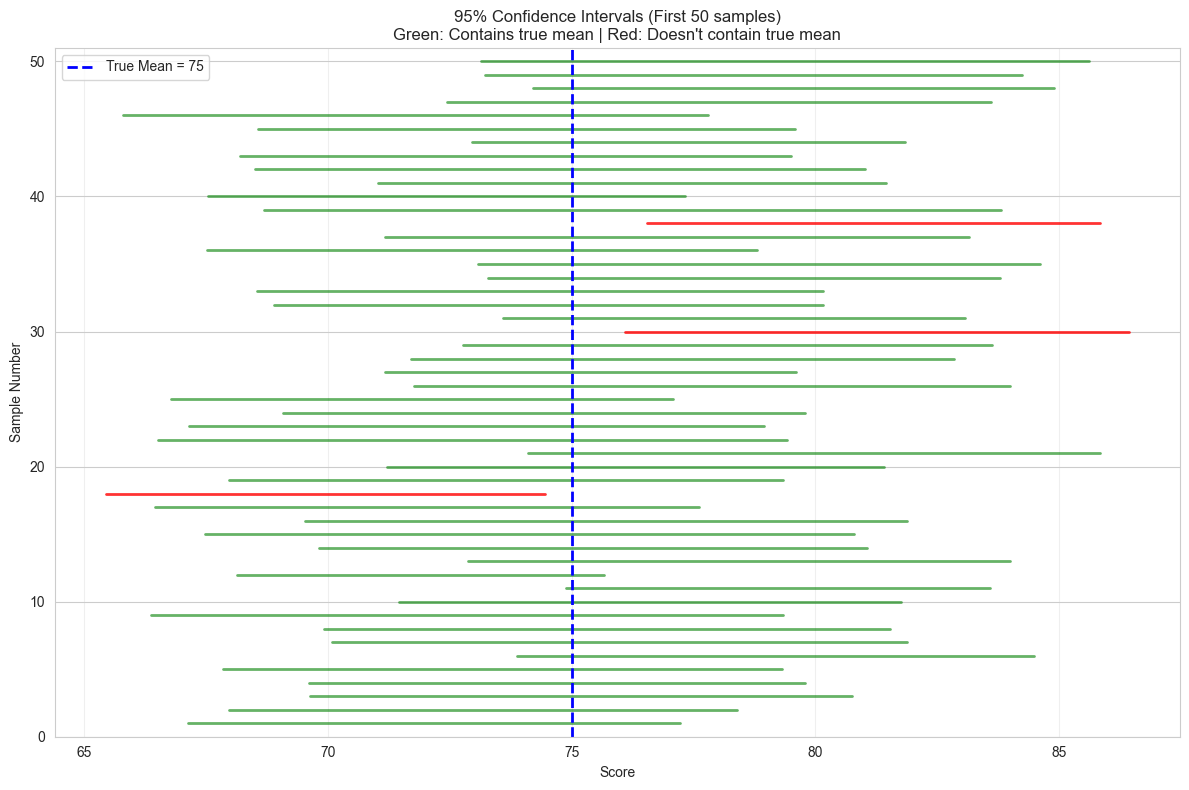

In [32]:
print("\n" + "="*60)
print("INTERPRETING CONFIDENCE INTERVALS")
print("="*60)

# Demonstrate CI with simulations
np.random.seed(42)
population_mean = 75
population_std = 15

num_samples = 100
sample_size = 30
confidence_level = 0.95
alpha = 1 - confidence_level

print(f"\nSimulation: Drawing {num_samples} samples of size {sample_size}")
print(f"True population mean: {population_mean}")
print(f"Confidence level: {confidence_level*100}%")

ci_contains_true_mean = 0
ci_list = []

for i in range(num_samples):
    sample = np.random.normal(population_mean, population_std, sample_size)
    sample_mean = sample.mean()
    sample_std = sample.std(ddof=1)
    standard_error = sample_std / np.sqrt(sample_size)
    
    t_critical = t.ppf(1 - alpha/2, df=sample_size-1)
    margin_of_error = t_critical * standard_error
    
    ci_lower = sample_mean - margin_of_error
    ci_upper = sample_mean + margin_of_error
    
    ci_list.append((ci_lower, ci_upper))
    
    if ci_lower <= population_mean <= ci_upper:
        ci_contains_true_mean += 1

print(f"\nResults:")
print(f"Number of CIs containing true mean: {ci_contains_true_mean}/{num_samples}")
print(f"Percentage: {ci_contains_true_mean/num_samples*100:.1f}%")
print(f"\nExpected: ~{confidence_level*100:.0f}% of CIs contain true mean")

# Visualization
fig, ax = plt.subplots(figsize=(12, 8))

# Plot first 50 CIs
y_positions = np.arange(1, 51)
for i in range(50):
    ci_lower, ci_upper = ci_list[i]
    if ci_lower <= population_mean <= ci_upper:
        color = 'green'
        alpha_val = 0.6
    else:
        color = 'red'
        alpha_val = 0.8
    
    ax.plot([ci_lower, ci_upper], [y_positions[i], y_positions[i]], 
            color=color, linewidth=2, alpha=alpha_val)

# Add true population mean line
ax.axvline(population_mean, color='blue', linestyle='--', linewidth=2, 
           label=f'True Mean = {population_mean}')

ax.set_xlabel('Score')
ax.set_ylabel('Sample Number')
ax.set_title(f'95% Confidence Intervals (First 50 samples)\nGreen: Contains true mean | Red: Doesn\'t contain true mean')
ax.set_ylim([0, 51])
ax.grid(True, alpha=0.3, axis='x')
ax.legend()

plt.tight_layout()
plt.show()

---
## Topic 4: Statistical Significance and Interpretation

### Concepts Covered:
- **P-Value**: Probability of observing test statistic under null hypothesis
- **T-Stats vs Z-Stats**: When to use each
- **Interpretation Rules**: What different p-values mean
- **Statistical vs Practical Significance**: Large n effects
- **Effect Size**: Magnitude of the effect

### Detailed Explanations:

#### P-Value Interpretation
- **p-value < 0.001**: Very strong evidence against H₀
- **p-value < 0.01**: Strong evidence against H₀
- **p-value < 0.05**: Moderate evidence against H₀
- **p-value < 0.10**: Weak evidence against H₀
- **p-value >= 0.10**: Little to no evidence against H₀

#### Statistical vs Practical Significance
- Statistical significance: Result unlikely due to chance (p < 0.05)
- Practical significance: Result is meaningful in real-world context
- Large samples can show statistical significance with small effect sizes
- Always report effect size along with p-value

### Exercise 8.1: P-Value Interpretation

In [33]:
print("\n" + "="*60)
print("P-VALUE INTERPRETATION")
print("="*60)

print("\nP-Value: Probability of observing the data IF null hypothesis is true")
print("\nCommon Misconceptions:")
print()

misconceptions = pd.DataFrame({
    'Misconception': [
        'p-value = probability H₀ is true',
        'p-value = probability results are due to chance',
        'p-value tells us effect size',
        'p < 0.05 = proof of effect'
    ],
    'Truth': [
        'p-value = probability of data if H₀ is true',
        'Results ALWAYS have random variation',
        'p-value just indicates significance, not magnitude',
        'p < 0.05 = evidence against H₀, not proof'
    ]
})

print(misconceptions.to_string(index=False))

print("\n" + "="*60)
print("P-Value Decision Rules:")
print("="*60)

p_values = [0.001, 0.01, 0.03, 0.05, 0.07, 0.15]
alpha = 0.05

print(f"\nUsing α = {alpha}")
print()
print("P-Value | Decision | Strength of Evidence")
print("-" * 50)

for p in p_values:
    if p < 0.001:
        strength = "Very strong evidence against H₀"
        decision = "Reject H₀"
    elif p < 0.01:
        strength = "Strong evidence against H₀"
        decision = "Reject H₀"
    elif p < 0.05:
        strength = "Moderate evidence against H₀"
        decision = "Reject H₀"
    else:
        strength = "Weak or no evidence against H₀"
        decision = "Fail to reject H₀"
    
    print(f" {p:0.3f}  | {decision:15s} | {strength}")


P-VALUE INTERPRETATION

P-Value: Probability of observing the data IF null hypothesis is true

Common Misconceptions:

                                  Misconception                                              Truth
               p-value = probability H₀ is true        p-value = probability of data if H₀ is true
p-value = probability results are due to chance               Results ALWAYS have random variation
                   p-value tells us effect size p-value just indicates significance, not magnitude
                     p < 0.05 = proof of effect          p < 0.05 = evidence against H₀, not proof

P-Value Decision Rules:

Using α = 0.05

P-Value | Decision | Strength of Evidence
--------------------------------------------------
 0.001  | Reject H₀       | Strong evidence against H₀
 0.010  | Reject H₀       | Moderate evidence against H₀
 0.030  | Reject H₀       | Moderate evidence against H₀
 0.050  | Fail to reject H₀ | Weak or no evidence against H₀
 0.070  | Fail to re

### Exercise 8.2: Effect Size - Cohen's d

In [34]:
print("\n" + "="*60)
print("EFFECT SIZE: COHEN'S D")
print("="*60)

# Compare two groups
group1 = np.random.normal(75, 12, 50)
group2 = np.random.normal(80, 12, 50)

mean1 = group1.mean()
mean2 = group2.mean()
std1 = group1.std(ddof=1)
std2 = group2.std(ddof=1)
n1, n2 = len(group1), len(group2)

# Calculate pooled standard deviation
pooled_std = np.sqrt(((n1-1)*std1**2 + (n2-1)*std2**2) / (n1+n2-2))

# Cohen's d
cohens_d = (mean2 - mean1) / pooled_std

print(f"\nGroup 1: Mean = {mean1:.2f}, SD = {std1:.2f}")
print(f"Group 2: Mean = {mean2:.2f}, SD = {std2:.2f}")
print(f"\nCohen's d = (μ₂ - μ₁) / σ_pooled")
print(f"Cohen's d = ({mean2:.2f} - {mean1:.2f}) / {pooled_std:.2f}")
print(f"Cohen's d = {cohens_d:.4f}")

print(f"\nEffect Size Interpretation:")
print(f"  |d| < 0.2  : Negligible effect")
print(f"  0.2 ≤ |d| < 0.5  : Small effect")
print(f"  0.5 ≤ |d| < 0.8  : Medium effect")
print(f"  |d| ≥ 0.8  : Large effect")

if abs(cohens_d) < 0.2:
    effect = "Negligible"
elif abs(cohens_d) < 0.5:
    effect = "Small"
elif abs(cohens_d) < 0.8:
    effect = "Medium"
else:
    effect = "Large"

print(f"\nConclusion: This is a {effect} effect size.")

# Statistical test
t_stat, p_value = stats.ttest_ind(group1, group2)
print(f"\nStatistical Test:")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"\nConclusion:")
print(f"Statistical significance (p): {'Yes' if p_value < 0.05 else 'No'} (p {'<' if p_value < 0.05 else '>'} 0.05)")
print(f"Practical significance (d): {effect} effect (|d| = {abs(cohens_d):.3f})")


EFFECT SIZE: COHEN'S D

Group 1: Mean = 72.27, SD = 12.63
Group 2: Mean = 80.19, SD = 11.83

Cohen's d = (μ₂ - μ₁) / σ_pooled
Cohen's d = (80.19 - 72.27) / 12.23
Cohen's d = 0.6475

Effect Size Interpretation:
  |d| < 0.2  : Negligible effect
  0.2 ≤ |d| < 0.5  : Small effect
  0.5 ≤ |d| < 0.8  : Medium effect
  |d| ≥ 0.8  : Large effect

Conclusion: This is a Medium effect size.

Statistical Test:
t-statistic: -3.2377
p-value: 0.001645

Conclusion:
Statistical significance (p): Yes (p < 0.05)
Practical significance (d): Medium effect (|d| = 0.648)


### Exercise 8.3: Summary of All Tests Performed

In [35]:
print("\n" + "="*70)
print("COMPREHENSIVE SUMMARY OF HYPOTHESIS TESTS")
print("="*70)

summary = pd.DataFrame({
    'Test': [
        'Z-Test',
        'T-Test (One Sample)',
        'T-Test (Independent)',
        'T-Test (Paired)',
        'Chi-Square Goodness',
        'Chi-Square Independence',
        'ANOVA'
    ],
    'When to Use': [
        'σ known or n > 30',
        'σ unknown, test mean',
        'Compare 2 group means',
        'Same subjects, 2 times',
        'Test if data fits distribution',
        'Test relationship between categorical',
        'Compare 3+ group means'
    ],
    'Test Statistic': [
        'Z = (x̄ - μ)/(σ/√n)',
        't = (x̄ - μ)/(s/√n)',
        't = (x̄₁ - x̄₂)/SE',
        't = d̄/(sd/√n)',
        'χ² = Σ(O-E)²/E',
        'χ² contingency table',
        'F = MS_between/MS_within'
    ],
    'Assumptions': [
        'Normal distribution',
        'Normal, independent samples',
        'Normal, equal variances',
        'Normal differences',
        'Counts, expected ≥ 5',
        'Counts, expected ≥ 5',
        'Normal, equal variances'
    ]
})

print(summary.to_string(index=False))

print("\n" + "="*70)
print("KEY FORMULAS")
print("="*70)

formulas = pd.DataFrame({
    'Concept': [
        'Standard Error',
        'Confidence Interval',
        'Test Statistic',
        'Margin of Error',
        'Cohens d',
        'Sample Size',
        'Z-score'
    ],
    'Formula': [
        'SE = σ/√n',
        'Point Est ± (Critical × SE)',
        't = (x̄ - μ)/SE',
        'ME = t_critical × SE',
        'd = (μ₁ - μ₂)/σ_pooled',
        'n = (Z_α × σ / ME)²',
        'Z = (X - μ)/σ'
    ]
})

print(formulas.to_string(index=False))


COMPREHENSIVE SUMMARY OF HYPOTHESIS TESTS
                   Test                           When to Use           Test Statistic                 Assumptions
                 Z-Test                     σ known or n > 30      Z = (x̄ - μ)/(σ/√n)         Normal distribution
    T-Test (One Sample)                  σ unknown, test mean      t = (x̄ - μ)/(s/√n) Normal, independent samples
   T-Test (Independent)                 Compare 2 group means       t = (x̄₁ - x̄₂)/SE     Normal, equal variances
        T-Test (Paired)                Same subjects, 2 times           t = d̄/(sd/√n)          Normal differences
    Chi-Square Goodness        Test if data fits distribution           χ² = Σ(O-E)²/E        Counts, expected ≥ 5
Chi-Square Independence Test relationship between categorical     χ² contingency table        Counts, expected ≥ 5
                  ANOVA                Compare 3+ group means F = MS_between/MS_within     Normal, equal variances

KEY FORMULAS
            Concept    

---
# COMPREHENSIVE EXERCISES - Apply All Concepts

## Capstone Project: Complete Data Analysis

### Exercise 9: Complete Statistical Analysis of Student Performance

In [36]:
print("\n" + "="*70)
print("CAPSTONE PROJECT: COMPREHENSIVE STATISTICAL ANALYSIS")
print("="*70)
print("\nObjective: Analyze student performance data using all concepts learned")
print()

# 1. Descriptive Statistics
print("\n1. DESCRIPTIVE STATISTICS")
print("-" * 70)

desc_stats = df_students[['Math_Score', 'Science_Score', 'English_Score']].describe()
print(desc_stats.round(2))

# 2. Data Quality Check
print("\n2. DATA QUALITY CHECK")
print("-" * 70)
print(f"Missing values:")
print(df_students.isnull().sum())
print(f"\nData types:")
print(df_students.dtypes)

# 3. Distribution Analysis
print("\n3. DISTRIBUTION ANALYSIS")
print("-" * 70)

for col in ['Math_Score', 'Science_Score', 'English_Score']:
    skewness = skew(df_students[col])
    kurt = kurtosis(df_students[col])
    shapiro_stat, shapiro_p = stats.shapiro(df_students[col])
    print(f"\n{col}:")
    print(f"  Skewness: {skewness:.4f}")
    print(f"  Kurtosis: {kurt:.4f}")
    print(f"  Normality test p-value: {shapiro_p:.6f} ({'Normal' if shapiro_p > 0.05 else 'Not Normal'})")

# 4. Hypothesis Tests
print("\n4. HYPOTHESIS TESTS")
print("-" * 70)

# Test 1: Is mean Math score significantly different from 75?
from scipy.stats import ttest_1samp
t_stat, p_val = ttest_1samp(df_students['Math_Score'], 75)
print(f"\nTest 1: One-sample t-test (H₀: μ_math = 75)")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_val:.6f}")
print(f"  Result: {'Reject H₀' if p_val < 0.05 else 'Fail to reject H₀'}")

# Test 2: Difference between genders
male_math = df_students[df_students['Gender'] == 'Male']['Math_Score']
female_math = df_students[df_students['Gender'] == 'Female']['Math_Score']
t_stat, p_val = stats.ttest_ind(male_math, female_math)
print(f"\nTest 2: Independent t-test (Gender difference in Math)")
print(f"  Male mean: {male_math.mean():.2f}, Female mean: {female_math.mean():.2f}")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_val:.6f}")
print(f"  Result: {'Significant difference' if p_val < 0.05 else 'No significant difference'}")

# Test 3: Chi-square test
df_students['Pass_Fail'] = df_students['Math_Score'].apply(lambda x: 'Pass' if x >= 70 else 'Fail')
contingency = pd.crosstab(df_students['Gender'], df_students['Pass_Fail'])
chi2_stat, chi2_p, _, _ = stats.chi2_contingency(contingency)
print(f"\nTest 3: Chi-square test (Gender vs Pass/Fail)")
print(f"  χ² statistic: {chi2_stat:.4f}")
print(f"  p-value: {chi2_p:.6f}")
print(f"  Result: {'Variables are dependent' if chi2_p < 0.05 else 'Variables are independent'}")

# 5. Effect Sizes
print("\n5. EFFECT SIZES")
print("-" * 70)

pooled_std = np.sqrt(((len(male_math)-1)*male_math.std()**2 + 
                       (len(female_math)-1)*female_math.std()**2) / 
                      (len(male_math) + len(female_math) - 2))
cohens_d = (male_math.mean() - female_math.mean()) / pooled_std

print(f"\nCohen's d (Math score by Gender):")
print(f"  d = {cohens_d:.4f}")
if abs(cohens_d) < 0.2:
    interpretation = "Negligible effect"
elif abs(cohens_d) < 0.5:
    interpretation = "Small effect"
elif abs(cohens_d) < 0.8:
    interpretation = "Medium effect"
else:
    interpretation = "Large effect"
print(f"  Interpretation: {interpretation}")

# 6. Confidence Intervals
print("\n6. CONFIDENCE INTERVALS (95%)")
print("-" * 70)

for col in ['Math_Score', 'Science_Score', 'English_Score']:
    mean = df_students[col].mean()
    se = df_students[col].sem()
    ci = t.ppf(0.975, len(df_students)-1) * se
    print(f"\n{col}: {mean:.2f} ± {ci:.2f}")
    print(f"  95% CI: [{mean-ci:.2f}, {mean+ci:.2f}]")

# 7. Correlation Analysis
print("\n7. CORRELATION ANALYSIS")
print("-" * 70)

corr = df_students[['Study_Hours', 'Math_Score', 'Science_Score', 'English_Score']].corr()
print(f"\nCorrelation with Study Hours:")
print(corr['Study_Hours'].round(3))

print("\n" + "="*70)
print("ANALYSIS COMPLETE!")
print("="*70)


CAPSTONE PROJECT: COMPREHENSIVE STATISTICAL ANALYSIS

Objective: Analyze student performance data using all concepts learned


1. DESCRIPTIVE STATISTICS
----------------------------------------------------------------------
       Math_Score  Science_Score  English_Score
count      100.00         100.00         100.00
mean        75.33          72.91          71.71
std         14.31          15.18          14.15
min         46.22          26.62          36.02
25%         62.92          62.82          60.93
50%         76.26          73.37          70.80
75%         83.07          81.86          80.94
max        115.80         125.94         105.04

2. DATA QUALITY CHECK
----------------------------------------------------------------------
Missing values:
Student_ID       0
Age              0
Math_Score       0
Science_Score    0
English_Score    0
Gender           0
Study_Hours      0
Pass_Fail        0
dtype: int64

Data types:
Student_ID         int64
Age                int64
Math_

---
# PRACTICE EXERCISES WITH SOLUTIONS

## Set 1: Basic Concepts

In [37]:
print("\n" + "="*70)
print("PRACTICE EXERCISES - SET 1: BASIC CONCEPTS")
print("="*70)

print("\nExercise 1.1: Dice Probability")
print("-" * 50)
print("Question: If you roll a fair die, what's P(rolling a 3 or 4)?")
print("\nSolution:")
p_3_or_4 = 2/6
print(f"P(3 or 4) = P(3) + P(4) = 1/6 + 1/6 = {p_3_or_4:.4f} or {p_3_or_4*100:.1f}%")

print("\n" + "-" * 50)
print("Exercise 1.2: Coin Flip Probability")
print("-" * 50)
print("Question: If you flip a fair coin 5 times, what's P(exactly 3 heads)?")
print("\nSolution:")
from math import comb
n, k, p = 5, 3, 0.5
prob = comb(n, k) * (p**k) * ((1-p)**(n-k))
print(f"Using Binomial: P(X=3) = C(5,3) × 0.5³ × 0.5²")
print(f"              = 10 × 0.125 × 0.25")
print(f"              = {prob:.4f} or {prob*100:.1f}%")

print("\n" + "-" * 50)
print("Exercise 1.3: Empirical Rule")
print("-" * 50)
print("Question: In a normal distribution with μ=100, σ=15,")
print("          what % of data falls between 70 and 130?")
print("\nSolution:")
mu, sigma = 100, 15
prob_between = norm.cdf(130, mu, sigma) - norm.cdf(70, mu, sigma)
print(f"70 and 130 are μ ± 2σ")
print(f"By empirical rule: ~95% of data (theoretical: {prob_between*100:.2f}%)")


PRACTICE EXERCISES - SET 1: BASIC CONCEPTS

Exercise 1.1: Dice Probability
--------------------------------------------------
Question: If you roll a fair die, what's P(rolling a 3 or 4)?

Solution:
P(3 or 4) = P(3) + P(4) = 1/6 + 1/6 = 0.3333 or 33.3%

--------------------------------------------------
Exercise 1.2: Coin Flip Probability
--------------------------------------------------
Question: If you flip a fair coin 5 times, what's P(exactly 3 heads)?

Solution:
Using Binomial: P(X=3) = C(5,3) × 0.5³ × 0.5²
              = 10 × 0.125 × 0.25
              = 0.3125 or 31.2%

--------------------------------------------------
Exercise 1.3: Empirical Rule
--------------------------------------------------
Question: In a normal distribution with μ=100, σ=15,
          what % of data falls between 70 and 130?

Solution:
70 and 130 are μ ± 2σ
By empirical rule: ~95% of data (theoretical: 95.45%)


## Set 2: Hypothesis Testing

In [38]:
print("\n" + "="*70)
print("PRACTICE EXERCISES - SET 2: HYPOTHESIS TESTING")
print("="*70)

print("\nExercise 2.1: Sample Size Calculation")
print("-" * 50)
print("Question: How many samples needed to estimate population mean")
print("          with 95% confidence and ±5 point margin of error?")
print("          (Assume σ = 20)")
print("\nSolution:")
z_alpha = norm.ppf(0.975)  # 95% confidence
sigma = 20
margin_of_error = 5
n_required = ((z_alpha * sigma / margin_of_error) ** 2)
print(f"n = (Z_α/2 × σ / ME)²")
print(f"n = ({z_alpha:.3f} × {sigma} / {margin_of_error})²")
print(f"n = ({z_alpha:.3f} × 4)²")
print(f"n = {n_required:.0f}")
print(f"\nAnswer: Need approximately {int(np.ceil(n_required))} samples")

print("\n" + "-" * 50)
print("Exercise 2.2: Interpreting P-value")
print("-" * 50)
print("Question: Your t-test gives p-value = 0.0234")
print("          Using α = 0.05, what's your conclusion?")
print("\nSolution:")
p_value = 0.0234
alpha = 0.05
print(f"p-value ({p_value}) < α ({alpha})")
print(f"Conclusion: REJECT the null hypothesis")
print(f"            We have statistically significant evidence.")
print(f"            If H₀ were true, we'd see this data only 2.34% of the time.")


PRACTICE EXERCISES - SET 2: HYPOTHESIS TESTING

Exercise 2.1: Sample Size Calculation
--------------------------------------------------
Question: How many samples needed to estimate population mean
          with 95% confidence and ±5 point margin of error?
          (Assume σ = 20)

Solution:
n = (Z_α/2 × σ / ME)²
n = (1.960 × 20 / 5)²
n = (1.960 × 4)²
n = 61

Answer: Need approximately 62 samples

--------------------------------------------------
Exercise 2.2: Interpreting P-value
--------------------------------------------------
Question: Your t-test gives p-value = 0.0234
          Using α = 0.05, what's your conclusion?

Solution:
p-value (0.0234) < α (0.05)
Conclusion: REJECT the null hypothesis
            We have statistically significant evidence.
            If H₀ were true, we'd see this data only 2.34% of the time.


---
# END OF COMPREHENSIVE COURSE

## Key Takeaways

This comprehensive guide covered:

1. **Descriptive Statistics**: Measures of central tendency and dispersion
2. **Probability Basics**: Random variables, probability rules, distributions
3. **Probability Distributions**: Binomial, Poisson, Normal, and others
4. **Statistical Inference**: Hypothesis testing, confidence intervals
5. **Advanced Testing**: T-tests, Chi-square tests, ANOVA
6. **Bayesian Statistics**: Prior beliefs and posterior probabilities
7. **Effect Sizes and Significance**: Practical vs statistical significance

## Next Steps

1. Practice with real datasets
2. Master statistical software (Python, R, SPSS)
3. Learn advanced topics (Regression, Time Series, Machine Learning)
4. Understand research design and experimental methodology
5. Develop critical thinking about data interpretation

In [39]:
print("\n" + "="*70)
print("STATISTICS & PROBABILITY COURSE COMPLETED")
print("="*70)
print("\nCongratulations on completing this comprehensive course!")
print("\nYou've learned:")
print("  ✓ Descriptive Statistics")
print("  ✓ Probability Theory")
print("  ✓ Distributions (Binomial, Poisson, Normal)")
print("  ✓ Hypothesis Testing")
print("  ✓ Confidence Intervals")
print("  ✓ T-tests and Z-tests")
print("  ✓ Chi-Square Tests")
print("  ✓ Bayes' Theorem")
print("  ✓ Effect Sizes")
print("  ✓ Statistical Interpretation")
print("\nUse these skills wisely in your data analysis journey!")
print("="*70)


STATISTICS & PROBABILITY COURSE COMPLETED

Congratulations on completing this comprehensive course!

You've learned:
  ✓ Descriptive Statistics
  ✓ Probability Theory
  ✓ Distributions (Binomial, Poisson, Normal)
  ✓ Hypothesis Testing
  ✓ Confidence Intervals
  ✓ T-tests and Z-tests
  ✓ Chi-Square Tests
  ✓ Bayes' Theorem
  ✓ Effect Sizes
  ✓ Statistical Interpretation

Use these skills wisely in your data analysis journey!
